# Análise qualitativa — alvo, probabilidade predita e predição binarizada

Gera duas figuras (`qualitative_analysis_maceio.png` e `qualitative_analysis_arapiraca.png`) com $3$ amostras representativas do conjunto de validação por cidade, cada amostra ilustrada com três painéis lado a lado:
1. **Alvo real** ($y$): mapa binário $16 \times 16$ que o modelo deveria prever.
2. **Probabilidade predita** ($\hat{p}$): saída contínua da rede após sigmoide, em $[0, 1]$.
3. **Predição binarizada** ($\hat{y} = \mathbb{1}[\hat{p} \geq \tau^*]$) no limiar ótimo de F1 espacial.

Limiares ótimos:
- Maceió: $\tau^* = 0{,}68$
- Arapiraca: $\tau^* = 0{,}62$

**Entrada:** `./output/{cidade}/predictions/convlstm_{predictions,targets}_{cidade}_42.pkl`

**Saída:** `./crime_deeping_learning/figuras/qualitative_analysis_{cidade}.png`

## 1. Configuração e funções

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

FIG_DIR = Path("./crime_deeping_learning/figuras")
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
N_SAMPLES = 3                  # quantas amostras mostrar por cidade
MIN_TARGET_POSITIVES = 3       # filtrar amostras com pelo menos 3 positivos no alvo, para clareza

OPTIMAL_THRESHOLDS = {
    "maceio":    0.68,
    "arapiraca": 0.62,
}

def load_predictions_targets(city):
    """Carrega arrays de predições e alvos do conjunto de validação."""
    base = Path(f"./output/{city}/predictions")
    with open(base / f"convlstm_predictions_{city}_42.pkl", "rb") as f:
        preds = pickle.load(f)
    with open(base / f"convlstm_targets_{city}_42.pkl", "rb") as f:
        targets = pickle.load(f)
    return preds, targets

for city in ["maceio", "arapiraca"]:
    preds, targets = load_predictions_targets(city)
    print(f"{city}: preds shape = {preds.shape}, targets shape = {targets.shape}")

maceio: preds shape = (3024, 16, 16), targets shape = (3024, 16, 16)
arapiraca: preds shape = (2268, 16, 16), targets shape = (2268, 16, 16)


## 2. Função de renderização

Para cada cidade, sorteia `N_SAMPLES` amostras com pelo menos `MIN_TARGET_POSITIVES` ocorrências no alvo (para ter algo visível) e plota as três colunas lado a lado, com colormaps específicos para cada tipo de visualização.

maceio: amostras escolhidas = [281, 1937, 2304], τ* = 0.68


Salvo: crime_deeping_learning/figuras/qualitative_analysis_maceio.png


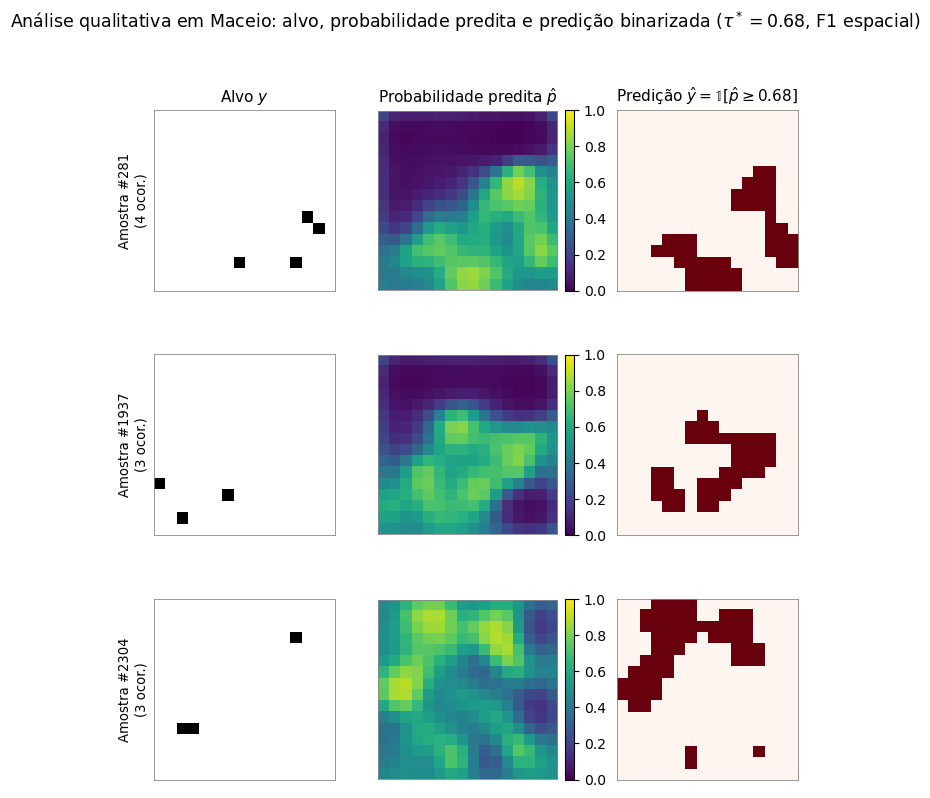

arapiraca: amostras escolhidas = [239, 1302, 1564], τ* = 0.62


Salvo: crime_deeping_learning/figuras/qualitative_analysis_arapiraca.png


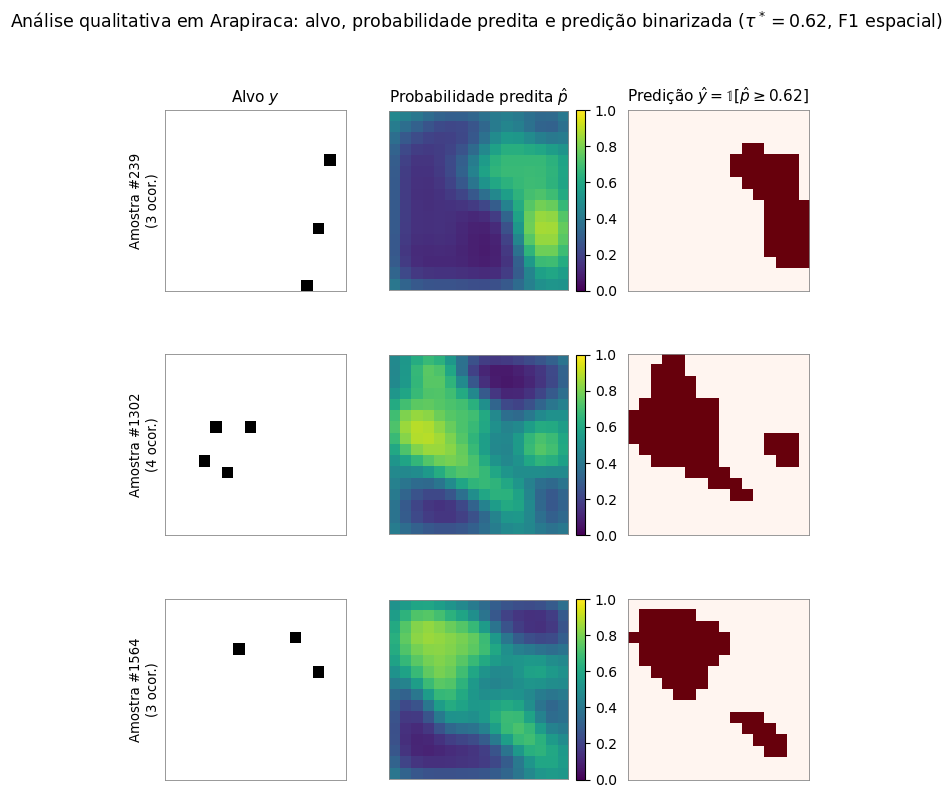

In [2]:
def render_city(city, n_samples=N_SAMPLES, min_pos=MIN_TARGET_POSITIVES, seed=SEED):
    preds, targets = load_predictions_targets(city)
    tau = OPTIMAL_THRESHOLDS[city]

    # Filtragem por número mínimo de positivos no alvo
    target_counts = np.array([int(np.nansum(targets[k])) for k in range(len(targets))])
    candidates = np.where(target_counts >= min_pos)[0]
    rng = np.random.default_rng(seed)
    idxs = rng.choice(candidates, size=min(n_samples, len(candidates)), replace=False)
    idxs = np.sort(idxs)

    print(f"{city}: amostras escolhidas = {idxs.tolist()}, τ* = {tau}")

    fig, axes = plt.subplots(
        n_samples, 3,
        figsize=(8.5, 2.9 * n_samples),
        gridspec_kw={"hspace": 0.35, "wspace": 0.18},
    )
    if n_samples == 1:
        axes = axes.reshape(1, -1)

    col_titles = [
        "Alvo $y$",
        "Probabilidade predita $\\hat{p}$",
        f"Predição $\\hat{{y}} = \\mathbb{{1}}[\\hat{{p}} \\geq {tau}]$",
    ]

    for r, idx in enumerate(idxs):
        target = np.nan_to_num(targets[idx], nan=0.0)
        prob = np.nan_to_num(preds[idx], nan=0.0)
        binar = (prob >= tau).astype(np.float32)

        # (a) target — preto/branco
        ax = axes[r, 0]
        ax.imshow(target, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(col_titles[0] if r == 0 else "", fontsize=11)
        ax.set_ylabel(f"Amostra #{idx}\n({int(target.sum())} ocor.)", fontsize=9.5)

        # (b) probabilidade — viridis
        ax = axes[r, 1]
        im = ax.imshow(prob, cmap="viridis", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(col_titles[1] if r == 0 else "", fontsize=11)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # (c) binarizada — vermelho
        ax = axes[r, 2]
        ax.imshow(binar, cmap="Reds", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(col_titles[2] if r == 0 else "", fontsize=11)

        for c in range(3):
            axes[r, c].set_xticks([])
            axes[r, c].set_yticks([])
            for spine in axes[r, c].spines.values():
                spine.set_edgecolor("#888888")
                spine.set_linewidth(0.6)

    fig.suptitle(
        f"Análise qualitativa em {city.title()}: alvo, probabilidade predita e predição binarizada ("
        f"$\\tau^* = {tau}$, F1 espacial)",
        fontsize=12.5, y=0.995,
    )
    out_path = FIG_DIR / f"qualitative_analysis_{city}.png"
    fig.savefig(out_path, dpi=140, bbox_inches="tight")
    print(f"Salvo: {out_path}")
    plt.show()
    plt.close(fig)

render_city("maceio")
render_city("arapiraca")